# Bangla Depression Classification — Kaggle Conference Notebook

**Dataset file:** `Dataset final_conference.xlsx`

This notebook is organized as one reproducible end-to-end pipeline for Bangla depression classification.

### Model Families

- **Classical ML:** Logistic Regression, Decision Tree, Random Forest, Naive Bayes, SVM, KNN, AdaBoost
- **Deep Learning:** Bi-LSTM, Bi-GRU, Feed-Forward Neural Network
- **Transformers:** BanglaBERT (`sagorsarker/bangla-bert-base`), BanglaBERT (`csebuetnlp/banglabert`), mBERT, XLM-RoBERTa, DistilBERT Multilingual

### Experimental Design

- One cleaned and standardized Bangla dataset
- Bangla-specific text preprocessing with stopword removal
- One fixed **70% / 15% / 15%** stratified Train / Validation / Test split
- Training-only fitting for TF-IDF vectorizers and neural tokenizers
- Model selection based on **Validation Macro F1**
- Final performance reporting on the untouched test set
- No manually entered performance metrics

> **Kaggle Note:** Add your Kaggle Dataset containing `Dataset final_conference.xlsx` through **Add Input / Add Data** before running this notebook.

In [1]:
# CELL 1 — Install / update required packages
# Kaggle usually already includes most of these packages.

!pip install -q openpyxl wordcloud transformers accelerate sentencepiece

In [2]:
# CELL 2 — Imports and reproducibility

import os
import re
import json
import time
import random
import warnings
import socket
import gc
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Bidirectional,
    GlobalAveragePooling1D,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

from wordcloud import WordCloud

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# Prevent TensorFlow from reserving the entire GPU so PyTorch transformers can run later.
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = Path("/kaggle/working/model_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

TensorFlow: 2.20.0
PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 1. Locate and Load the Kaggle Dataset

The Google Sheets URL from the original notebook is removed. The code below searches Kaggle input directories automatically for `Dataset final_conference.xlsx`.

In [3]:
# CELL 3 — Find Dataset final_conference.xlsx automatically

DATASET_NAME = "Dataset final_conference.xlsx"

search_roots = [Path("/kaggle/input"), Path("/kaggle/working")]
candidates = []

for root in search_roots:
    if root.exists():
        candidates.extend(root.rglob(DATASET_NAME))

if not candidates:
    available_excel = []
    if Path("/kaggle/input").exists():
        available_excel = list(Path("/kaggle/input").rglob("*.xlsx"))

    print("Available Excel files:")
    for p in available_excel:
        print(" -", p)

    raise FileNotFoundError(
        f"Could not find '{DATASET_NAME}'. "
        "Attach the Kaggle dataset first using Add Input / Add Data."
    )

DATASET_PATH = candidates[0]
print("Dataset found:", DATASET_PATH)

Dataset found: /kaggle/input/datasets/perpendicooler/dataset-final-conference/Dataset final_conference.xlsx


In [4]:
# CELL 4 — Load the dataset once

df = pd.read_excel(DATASET_PATH)

required_columns = {"Data", "Type"}
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[["Data", "Type"]].copy()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset shape: (2635, 2)
Columns: ['Data', 'Type']


,Data,Type
0,যদি আজকে আমি বলি আমি সুইসাইড এর পর্যায়ে চলে গ...,Academic Depression
1,আমি একজন ফেইলিউরে পরিনিত হয়েছি । আমি এমন ছিলা...,Academic Depression
2,আত্মীয়রা যখন খোটা খোটি করে তখন নিজের প্রতি আত...,Academic Depression
3,এক্সাম নিয়ে মনে একটা হতাশা তৈরি হয়েছে ।আমি গত ...,Academic Depression
4,আমি মন দিয়ে পড়তে পারছি না।\nআমার নিজেকে পরাজি...,Academic Depression


In [5]:
# CELL 5 — Initial data quality check

print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print()
print("Raw target labels:")
print(sorted(df["Type"].dropna().astype(str).unique()))

print()
print("Exact duplicate rows:", df.duplicated().sum())

Missing values:


,Missing
Data,0
Type,0



Raw target labels:
['Academic Depression', 'Academic depression', 'Fear', 'Lonliness', 'Not Depressed', 'Not depressed', 'Situational Depression', 'Situational depression', 'not Depressed', 'not depressed', 'situational depression']

Exact duplicate rows: 10


## 2. Data Cleaning, Bangla Stopword Removal, and Label Standardization

Cleaning is performed only once here, before any train/validation/test split.

The text cleaner keeps Bangla Unicode characters and digits, removes Latin letters, emojis, URLs, punctuation, extra whitespace, and then removes a fixed reproducible list of common Bangla stopwords.


In [6]:
# CELL 6 — Standardize target labels

LABEL_REPLACEMENTS = {
    "not depressed": "Not Depressed",
    "Not depressed": "Not Depressed",
    "not Depressed": "Not Depressed",
    "situational depression": "Situational Depression",
    "Situational depression": "Situational Depression",
    "academic depression": "Academic Depression",
    "Academic depression": "Academic Depression",
    "lonliness": "Lonliness",
    "fear": "Fear",
}

df["Type"] = (
    df["Type"]
    .fillna("")
    .astype(str)
    .str.strip()
    .replace(LABEL_REPLACEMENTS)
)

print("Standardized labels:")
print(sorted(df["Type"].unique()))
print()
print("Class counts:")
display(df["Type"].value_counts().to_frame("Count"))

Standardized labels:
['Academic Depression', 'Fear', 'Lonliness', 'Not Depressed', 'Situational Depression']

Class counts:


,Count
Type,
Not Depressed,573
Lonliness,517
Situational Depression,516
Fear,515
Academic Depression,514


In [7]:
# ============================================================
# SELF-CONTAINED CELL — LOAD STOPWORDS + SHOW COMPARISON
# ============================================================

import os
import re
import pandas as pd

# ------------------------------------------------------------
# 1. LOAD BANGLA STOPWORDS
# ------------------------------------------------------------

STOPWORD_DIR = "/kaggle/input/datasets/shohanursobuj/bangla-stopwords"

if not os.path.exists(STOPWORD_DIR):
    STOPWORD_DIR = "/kaggle/input/bangla-stopwords"

if not os.path.exists(STOPWORD_DIR):
    raise FileNotFoundError(
        "Bangla stopword dataset not found. "
        "Please add 'shohanursobuj/bangla-stopwords' to your Kaggle notebook."
    )


# Find stopword file
all_files = []

for root, dirs, files in os.walk(STOPWORD_DIR):
    for file in files:
        all_files.append(os.path.join(root, file))


supported_extensions = (".txt", ".csv", ".xlsx", ".xls", ".json")

stopword_files = [
    file for file in all_files
    if file.lower().endswith(supported_extensions)
]

if len(stopword_files) == 0:
    raise FileNotFoundError("No supported stopword file found.")


# Prefer file containing "stop"
preferred_files = [
    file for file in stopword_files
    if "stop" in os.path.basename(file).lower()
]

STOPWORD_PATH = (
    preferred_files[0]
    if preferred_files
    else stopword_files[0]
)

print("Stopword file:")
print(STOPWORD_PATH)


# ------------------------------------------------------------
# 2. READ STOPWORDS
# ------------------------------------------------------------

BANGLA_STOPWORDS = set()

extension = os.path.splitext(STOPWORD_PATH)[1].lower()


if extension == ".txt":

    text = None

    for encoding in ["utf-8", "utf-8-sig", "utf-16"]:
        try:
            with open(STOPWORD_PATH, "r", encoding=encoding) as f:
                text = f.read()
            break
        except UnicodeError:
            pass

    if text is None:
        raise UnicodeError("Could not decode stopword file.")

    words = re.split(r"[\n,\r\t]+", text)

    for word in words:
        word = word.strip().strip("'\"[](){} ")

        if word:
            BANGLA_STOPWORDS.add(word)


elif extension == ".csv":

    stop_df = pd.read_csv(STOPWORD_PATH, header=None)

    for value in stop_df.values.flatten():

        if pd.notna(value):

            word = str(value).strip().strip("'\"[](){} ")

            if word:
                BANGLA_STOPWORDS.add(word)


elif extension in [".xlsx", ".xls"]:

    stop_df = pd.read_excel(STOPWORD_PATH, header=None)

    for value in stop_df.values.flatten():

        if pd.notna(value):

            word = str(value).strip().strip("'\"[](){} ")

            if word:
                BANGLA_STOPWORDS.add(word)


elif extension == ".json":

    import json

    with open(STOPWORD_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, list):

        for word in data:
            word = str(word).strip()

            if word:
                BANGLA_STOPWORDS.add(word)

    elif isinstance(data, dict):

        for key, value in data.items():

            if isinstance(value, list):

                for word in value:
                    word = str(word).strip()

                    if word:
                        BANGLA_STOPWORDS.add(word)

            else:

                word = str(key).strip()

                if word:
                    BANGLA_STOPWORDS.add(word)


print("\nNumber of stopwords loaded:", len(BANGLA_STOPWORDS))


# ------------------------------------------------------------
# 3. BASIC TEXT CLEANING
# ------------------------------------------------------------

def basic_bangla_clean(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Keep Bangla, numbers and spaces
    text = re.sub(
        r"[^\u0980-\u09FF0-9\s]",
        " ",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


# ------------------------------------------------------------
# 4. REMOVE STOPWORDS
# ------------------------------------------------------------

def remove_bangla_stopwords(text):

    cleaned = basic_bangla_clean(text)

    tokens = cleaned.split()

    filtered = [
        token
        for token in tokens
        if token not in BANGLA_STOPWORDS
    ]

    return " ".join(filtered)


# ------------------------------------------------------------
# 5. SHOW WHICH STOPWORDS WERE REMOVED
# ------------------------------------------------------------

def get_removed_stopwords(text):

    cleaned = basic_bangla_clean(text)

    tokens = cleaned.split()

    removed = [
        token
        for token in tokens
        if token in BANGLA_STOPWORDS
    ]

    return ", ".join(removed)


# ------------------------------------------------------------
# 6. CHECK YOUR DATAFRAME COLUMNS
# ------------------------------------------------------------

print("\nAvailable dataframe columns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 7. AUTOMATICALLY SELECT TEXT COLUMN
# ------------------------------------------------------------

# Tries to find a likely text column first
possible_names = [
    "text",
    "Text",
    "sentence",
    "Sentence",
    "data_original",
    "Data_original",
    "original",
    "Original",
    "content",
    "Content"
]

TEXT_COLUMN = None

for col in possible_names:

    if col in df.columns:
        TEXT_COLUMN = col
        break


# If none found, choose the first object/string column
if TEXT_COLUMN is None:

    object_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()

    if len(object_columns) > 0:
        TEXT_COLUMN = object_columns[0]
    else:
        raise ValueError(
            "Could not automatically find a text column."
        )


print("\nSelected text column:")
print(TEXT_COLUMN)


# ------------------------------------------------------------
# 8. CREATE COMPARISON TABLE
# ------------------------------------------------------------

result_df = df[[TEXT_COLUMN]].head(10).copy()

result_df["Original Text"] = result_df[TEXT_COLUMN]

result_df["Removed Stopwords"] = (
    result_df[TEXT_COLUMN]
    .apply(get_removed_stopwords)
)

result_df["After Stopword Removal"] = (
    result_df[TEXT_COLUMN]
    .apply(remove_bangla_stopwords)
)


# Remove duplicate source column
result_df = result_df[
    [
        "Original Text",
        "Removed Stopwords",
        "After Stopword Removal"
    ]
]


# ------------------------------------------------------------
# 9. DISPLAY RESULT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("BANGLA STOPWORD REMOVAL EXAMPLES")
print("=" * 80)

display(result_df)

Stopword file:
/kaggle/input/datasets/shohanursobuj/bangla-stopwords/bangla_stopwords.xlsx

Number of stopwords loaded: 1464

Available dataframe columns:
['Data', 'Type']

Selected text column:
Data

BANGLA STOPWORD REMOVAL EXAMPLES


,Original Text,Removed Stopwords,After Stopword Removal
0,যদি আজকে আমি বলি আমি সুইসাইড এর পর্যায়ে চলে গ...,"যদি, আমি, আমি, এর, চলে, অনেকেই, করবে, কিন্তু, ...",আজকে বলি সুইসাইড পর্যায়ে গেছি হাসি তামাশা মার...
1,আমি একজন ফেইলিউরে পরিনিত হয়েছি । আমি এমন ছিলা...,"আমি, আমি, এমন, এখন",একজন ফেইলিউরে পরিনিত হয়েছি ছিলাম না ভালো স্টুড...
2,আত্মীয়রা যখন খোটা খোটি করে তখন নিজের প্রতি আত...,"যখন, করে, তখন, নিজের, প্রতি, যায়, প্রতি, যায়...",আত্মীয়রা খোটা খোটি আত্নবিদ্ধাস কমে পড়ালেখার ...
3,এক্সাম নিয়ে মনে একটা হতাশা তৈরি হয়েছে ।আমি গত ...,"নিয়ে, মনে, হয়েছে, আমি, গত, মধ্যে",এক্সাম একটা হতাশা তৈরি মাসে চারটা এক্সামের তিন...
4,আমি মন দিয়ে পড়তে পারছি না।\nআমার নিজেকে পরাজি...,"আমি, দিয়ে, আমার, নিজেকে, মনে, হচ্ছে",মন পড়তে পারছি না পরাজিত
5,আমি জানিনা আমি কবে আত্নহত্যা করি আমার অবস্থা ভ...,"আমি, আমি, কবে, করি, আমার, অবস্থা, এই, আমি, ব্য...",জানিনা আত্নহত্যা ভালো না পড়াশোনা পারছিনা টিচার...
6,সামান্য পড়া পড়তে ও আমার অনেক সময় লাগছে! মরে যে...,"সামান্য, ও, আমার, অনেক, যেতে, করছে",পড়া পড়তে সময় লাগছে মরে ইচ্ছে
7,আমি ম্যাথ আর ফিজিক্স পারিনা।সারাদিন মনে হয় মরে...,"আমি, আর, মনে, হয়, যাই",ম্যাথ ফিজিক্স পারিনা সারাদিন মরে
8,"আমি আমার পড়াশোনার গ্যাপ, চান্স না পাওয়া সবকিছু...","আমি, আমার, নিয়ে, খুব",পড়াশোনার গ্যাপ চান্স না পাওয়া সবকিছু মানসিকভাব...
9,এই সেমিস্টারে ছয়টা সাবজেক্টের তিনটাতেই ফেইল কর...,"এই, এখন, যে",সেমিস্টারে ছয়টা সাবজেক্টের তিনটাতেই ফেইল করেছি...


In [8]:
# ============================================================
# CELL 8 — Apply Cleaning + Remove Problematic Duplicates
# ============================================================

import re
import pandas as pd


# ------------------------------------------------------------
# 1. MAKE SURE STOPWORDS EXIST
# ------------------------------------------------------------

if "BANGLA_STOPWORDS" not in globals():
    raise NameError(
        "BANGLA_STOPWORDS is not loaded. "
        "Please run the stopword-loading cell first."
    )


# ------------------------------------------------------------
# 2. DEFINE BANGLA TEXT CLEANING FUNCTION
# ------------------------------------------------------------

def clean_bangla_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove emojis and pictographs
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "]+",
        flags=re.UNICODE
    )

    text = emoji_pattern.sub(" ", text)

    # Keep Bangla characters, numbers and spaces
    text = re.sub(
        r"[^\u0980-\u09FF0-9\s]",
        " ",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    # Remove stopwords
    tokens = text.split()

    tokens = [
        token
        for token in tokens
        if token not in BANGLA_STOPWORDS
    ]

    text = " ".join(tokens)

    # Final cleanup
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


# ------------------------------------------------------------
# 3. STORE ORIGINAL ROW COUNT
# ------------------------------------------------------------

original_rows = len(df)


# ------------------------------------------------------------
# 4. APPLY CLEANING
# ------------------------------------------------------------

df["Data"] = df["Data"].apply(clean_bangla_text)


# ------------------------------------------------------------
# 5. REMOVE EMPTY TEXT OR EMPTY TARGET
# ------------------------------------------------------------

df["Data"] = df["Data"].fillna("")
df["Type"] = df["Type"].fillna("")

empty_mask = (
    (df["Data"].str.strip() == "") |
    (df["Type"].str.strip() == "")
)

removed_empty = int(empty_mask.sum())

df = df.loc[~empty_mask].copy()


# ------------------------------------------------------------
# 6. REMOVE EXACT TEXT-LABEL DUPLICATES
# ------------------------------------------------------------

before_exact = len(df)

df = df.drop_duplicates(
    subset=["Data", "Type"]
).copy()

removed_exact = before_exact - len(df)


# ------------------------------------------------------------
# 7. FIND TEXT WITH CONFLICTING LABELS
# ------------------------------------------------------------

conflicting_texts = (
    df.groupby("Data")["Type"]
    .nunique()
    .loc[lambda x: x > 1]
    .index
)

removed_conflicts = int(
    df["Data"]
    .isin(conflicting_texts)
    .sum()
)


# ------------------------------------------------------------
# 8. REMOVE CONFLICTING TEXT
# ------------------------------------------------------------

df = df.loc[
    ~df["Data"].isin(conflicting_texts)
].copy()


# ------------------------------------------------------------
# 9. KEEP ONE ROW PER UNIQUE TEXT
# ------------------------------------------------------------

before_text_dedup = len(df)

df = (
    df
    .drop_duplicates(subset=["Data"])
    .reset_index(drop=True)
)

removed_text_dupes = (
    before_text_dedup - len(df)
)


# ------------------------------------------------------------
# 10. SHOW SUMMARY
# ------------------------------------------------------------

print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)

print("Original rows:", original_rows)

print(
    "Removed empty text/target rows:",
    removed_empty
)

print(
    "Removed exact text-label duplicates:",
    removed_exact
)

print(
    "Removed rows involved in conflicting labels:",
    removed_conflicts
)

print(
    "Removed remaining duplicate texts:",
    removed_text_dupes
)

print("Final cleaned rows:", len(df))


# ------------------------------------------------------------
# 11. CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nClean class distribution:")

display(
    df["Type"]
    .value_counts()
    .to_frame("Count")
)

DATA CLEANING SUMMARY
Original rows: 2635
Removed empty text/target rows: 2
Removed exact text-label duplicates: 20
Removed rows involved in conflicting labels: 2
Removed remaining duplicate texts: 0
Final cleaned rows: 2611

Clean class distribution:


,Count
Type,
Not Depressed,569
Situational Depression,514
Fear,514
Academic Depression,512
Lonliness,502


In [9]:
# CELL 9 — Save cleaned dataset

CLEAN_DATA_PATH = OUTPUT_DIR / "cleaned_Dataset_final.xlsx"
df.to_excel(CLEAN_DATA_PATH, index=False)
print("Saved:", CLEAN_DATA_PATH)

Saved: /kaggle/working/model_outputs/cleaned_Dataset_final.xlsx


## 3. Exploratory Data Analysis

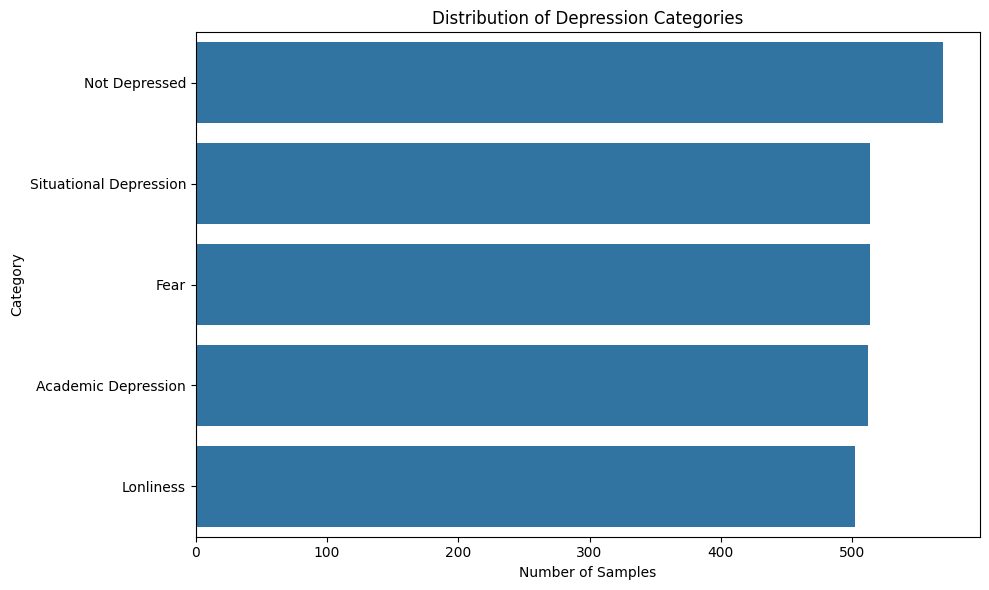

In [10]:
# CELL 10 — Class distribution

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Type",
    order=df["Type"].value_counts().index,
)

plt.title("Distribution of Depression Categories")
plt.xlabel("Number of Samples")
plt.ylabel("Category")
plt.tight_layout()

# Save figure
plt.savefig(
    "Distribution_of_Depression_Categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

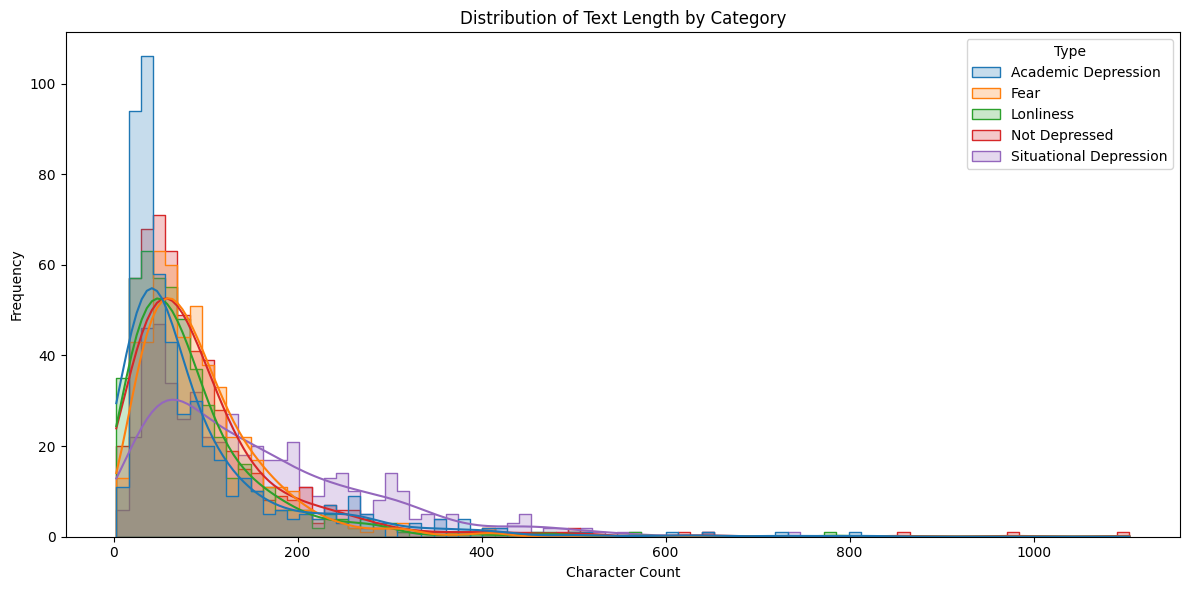

,count,mean,median,min,max
Type,,,,,
Academic Depression,512,91.27,54.0,6,811
Fear,514,94.86,78.0,8,519
Lonliness,502,86.41,64.5,3,782
Not Depressed,569,101.07,72.0,5,1104
Situational Depression,514,153.36,123.0,4,736


In [11]:
# CELL 11 — Text length analysis

df["text_length"] = df["Data"].str.len()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="Type",
    kde=True,
    element="step",
)
plt.title("Distribution of Text Length by Category")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

text_stats = (
    df.groupby("Type")["text_length"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
display(text_stats)

## 4. One Official Train / Validation / Test Split

The same **70/15/15 stratified split** is reused across **all** model families.


In [12]:
# CELL 12 — Create one fixed 70/15/15 stratified split

model_df = df[["Data", "Type"]].copy()

# First keep 15% as the final test set.
train_val_df, test_df = train_test_split(
    model_df,
    test_size=0.15,
    random_state=SEED,
    stratify=model_df["Type"],
)

# train_val_df contains 85% of the full data.
# Validation must be 15% of the full data:
# 0.15 / 0.85 = 0.1764705882 of train_val_df.
validation_fraction_of_train_val = 0.15 / 0.85

train_df, val_df = train_test_split(
    train_val_df,
    test_size=validation_fraction_of_train_val,
    random_state=SEED,
    stratify=train_val_df["Type"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

total_n = len(model_df)

print(f"Train:      {train_df.shape} ({len(train_df)/total_n:.2%})")
print(f"Validation: {val_df.shape} ({len(val_df)/total_n:.2%})")
print(f"Test:       {test_df.shape} ({len(test_df)/total_n:.2%})")

assert len(train_df) + len(val_df) + len(test_df) == total_n


Train:      (1827, 2) (69.97%)
Validation: (392, 2) (15.01%)
Test:       (392, 2) (15.01%)


In [13]:
# CELL 13 — Verify class proportions in each split

split_distribution = pd.concat(
    {
        "Train": train_df["Type"].value_counts(normalize=True),
        "Validation": val_df["Type"].value_counts(normalize=True),
        "Test": test_df["Type"].value_counts(normalize=True),
    },
    axis=1,
).fillna(0)

split_distribution = (split_distribution * 100).round(2)
display(split_distribution)

,Train,Validation,Test
Type,,,
Not Depressed,21.78,21.68,21.94
Fear,19.70,19.64,19.64
Situational Depression,19.70,19.64,19.64
Academic Depression,19.59,19.64,19.64
Lonliness,19.21,19.39,19.13


In [14]:
# CELL 14 — Save official split files

train_df.to_excel(OUTPUT_DIR / "train_data.xlsx", index=False)
val_df.to_excel(OUTPUT_DIR / "val_data.xlsx", index=False)
test_df.to_excel(OUTPUT_DIR / "test_data.xlsx", index=False)

print("Saved train_data.xlsx, val_data.xlsx and test_data.xlsx")

Saved train_data.xlsx, val_data.xlsx and test_data.xlsx


## 5. Shared Evaluation Utilities

The main selection metric is **Validation Macro F1** because this is a multi-class task and Macro F1 gives every class equal importance.

In [15]:
# CELL 15 — Shared evaluation helpers

ALL_CLASSES = sorted(model_df["Type"].unique())

results_records = []
test_predictions = {}
classification_reports = {}


def metric_bundle(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }


def add_model_result(
    category,
    model_name,
    y_val_true,
    y_val_pred,
    y_test_true,
    y_test_pred,
    training_time,
):
    val_metrics = metric_bundle(y_val_true, y_val_pred)
    test_metrics = metric_bundle(y_test_true, y_test_pred)

    record = {
        "Model Category": category,
        "Architecture": model_name,
        "Validation Accuracy": val_metrics["Accuracy"],
        "Validation Macro Precision": val_metrics["Macro Precision"],
        "Validation Macro Recall": val_metrics["Macro Recall"],
        "Validation Macro F1": val_metrics["Macro F1"],
        "Validation Weighted F1": val_metrics["Weighted F1"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Test Macro Precision": test_metrics["Macro Precision"],
        "Test Macro Recall": test_metrics["Macro Recall"],
        "Test Macro F1": test_metrics["Macro F1"],
        "Test Weighted F1": test_metrics["Weighted F1"],
        "Training Time (s)": training_time,
    }

    results_records.append(record)

    test_predictions[model_name] = {
        "y_true": list(y_test_true),
        "y_pred": list(y_test_pred),
    }

    classification_reports[model_name] = classification_report(
        y_test_true,
        y_test_pred,
        labels=ALL_CLASSES,
        target_names=ALL_CLASSES,
        zero_division=0,
    )

    return record


def plot_confusion_for_model(model_name):
    pred_data = test_predictions[model_name]
    cm = confusion_matrix(
        pred_data["y_true"],
        pred_data["y_pred"],
        labels=ALL_CLASSES,
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=ALL_CLASSES,
        yticklabels=ALL_CLASSES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()

# Part A — Classical Machine Learning

TF-IDF is fitted **only on the training data**. Validation and test sets are transformed using the same fitted vectorizer.

In [16]:
# CELL 16 — TF-IDF features

TFIDF_MAX_FEATURES = 20000

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["Data"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["Data"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["Data"])

y_train_ml = train_df["Type"]
y_val_ml = val_df["Type"]
y_test_ml = test_df["Type"]

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (1827, 2773)
Validation TF-IDF shape: (392, 2773)
Test TF-IDF shape: (392, 2773)


In [17]:
# CELL 17 — Define classical ML models

ml_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED,
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=SEED,
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
    ),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(
        class_weight="balanced",
        kernel="linear",
        random_state=SEED,
    ),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=SEED,
    ),
}

print("Classical models:", list(ml_models.keys()))

Classical models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM', 'KNN', 'AdaBoost']


In [18]:
# CELL 18 — Train and evaluate all classical ML models

ml_trained_models = {}

for name, model in ml_models.items():
    print("\n" + "=" * 75)
    print(name)
    print("=" * 75)

    start = time.time()
    model.fit(X_train_tfidf, y_train_ml)
    training_time = time.time() - start

    val_pred = model.predict(X_val_tfidf)
    test_pred = model.predict(X_test_tfidf)

    add_model_result(
        category="Classical ML",
        model_name=name,
        y_val_true=y_val_ml,
        y_val_pred=val_pred,
        y_test_true=y_test_ml,
        y_test_pred=test_pred,
        training_time=training_time,
    )

    ml_trained_models[name] = model
    print(classification_reports[name])


Logistic Regression
                        precision    recall  f1-score   support

   Academic Depression       0.60      0.65      0.62        77
                  Fear       0.95      0.70      0.81        77
             Lonliness       0.75      0.59      0.66        75
         Not Depressed       0.57      0.64      0.60        86
Situational Depression       0.49      0.61      0.54        77

              accuracy                           0.64       392
             macro avg       0.67      0.64      0.65       392
          weighted avg       0.67      0.64      0.65       392


Decision Tree
                        precision    recall  f1-score   support

   Academic Depression       0.52      0.66      0.58        77
                  Fear       0.82      0.70      0.76        77
             Lonliness       0.58      0.56      0.57        75
         Not Depressed       0.46      0.43      0.45        86
Situational Depression       0.42      0.42      0.42        77


In [19]:
# CELL 19 — Classical ML comparison

ml_results_df = (
    pd.DataFrame(results_records)
    .query("`Model Category` == 'Classical ML'")
    .sort_values("Validation Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(ml_results_df)

,Model Category,Architecture,Validation Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Validation Weighted F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Training Time (s)
0,Classical ML,Logistic Regression,0.663265,0.696977,0.661672,0.670448,0.669415,0.637755,0.670174,0.637448,0.646311,0.645295,0.896770
1,Classical ML,Random Forest,0.663265,0.677718,0.661848,0.665344,0.665632,0.632653,0.650539,0.632461,0.636245,0.635181,2.421060
2,Classical ML,SVM,0.640306,0.680511,0.638017,0.648417,0.647668,0.622449,0.659094,0.621725,0.631363,0.630493,0.404936
3,Classical ML,Naive Bayes,0.627551,0.651917,0.624614,0.628120,0.628385,0.604592,0.630181,0.603336,0.610756,0.610440,0.006426
4,Classical ML,AdaBoost,0.614796,0.675212,0.610053,0.618334,0.617311,0.602041,0.679907,0.597748,0.614577,0.612516,1.536380
5,Classical ML,Decision Tree,0.543367,0.545398,0.545324,0.544194,0.542834,0.551020,0.561095,0.553891,0.554723,0.552136,0.247249
6,Classical ML,KNN,0.255102,0.406036,0.256552,0.189655,0.190620,0.257653,0.378254,0.261415,0.203543,0.201994,0.002521


# Part B — Deep Learning

The Keras tokenizer is fitted **only on the training text**. The same 60/20/20 split is reused.

In [20]:
# CELL 20 — Deep learning tokenization and label encoding

MAX_WORDS = 10000
MAX_LEN = 200

keras_label_encoder = LabelEncoder()
keras_label_encoder.fit(train_df["Type"])

# Verify that every validation/test class was seen in training.
assert set(val_df["Type"]).issubset(set(keras_label_encoder.classes_))
assert set(test_df["Type"]).issubset(set(keras_label_encoder.classes_))

NUM_CLASSES = len(keras_label_encoder.classes_)

keras_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>",
)
keras_tokenizer.fit_on_texts(train_df["Data"])

X_train_seq = keras_tokenizer.texts_to_sequences(train_df["Data"])
X_val_seq = keras_tokenizer.texts_to_sequences(val_df["Data"])
X_test_seq = keras_tokenizer.texts_to_sequences(test_df["Data"])

X_train_pad = pad_sequences(
    X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_val_pad = pad_sequences(
    X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)

y_train_dl = keras_label_encoder.transform(train_df["Type"])
y_val_dl = keras_label_encoder.transform(val_df["Type"])
y_test_dl = keras_label_encoder.transform(test_df["Type"])

y_train_cat = to_categorical(y_train_dl, NUM_CLASSES)
y_val_cat = to_categorical(y_val_dl, NUM_CLASSES)

print("Classes:", list(keras_label_encoder.classes_))
print("Train shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Classes: ['Academic Depression', 'Fear', 'Lonliness', 'Not Depressed', 'Situational Depression']
Train shape: (1827, 200)
Validation shape: (392, 200)
Test shape: (392, 200)


In [21]:
# CELL 21 — Define deep learning architectures

def create_bilstm_model():
    model = Sequential([
        Embedding(MAX_WORDS, 128),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def create_bigru_model():
    model = Sequential([
        Embedding(MAX_WORDS, 128),
        Bidirectional(GRU(64)),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def create_ffnn_model():
    model = Sequential([
        Embedding(MAX_WORDS, 128),
        GlobalAveragePooling1D(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


dl_builders = {
    "Bi-LSTM": create_bilstm_model,
    "Bi-GRU": create_bigru_model,
    "Feed-Forward NN": create_ffnn_model,
}

In [22]:
# CELL 22 — Train and evaluate deep learning models

DL_EPOCHS = 5
DL_BATCH_SIZE = 32

dl_models_trained = {}
dl_histories = {}

for name, builder in dl_builders.items():
    print("\n" + "=" * 75)
    print("Training:", name)
    print("=" * 75)

    model = builder()

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )

    start = time.time()
    history = model.fit(
        X_train_pad,
        y_train_cat,
        validation_data=(X_val_pad, y_val_cat),
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1,
    )
    training_time = time.time() - start

    val_pred_int = np.argmax(model.predict(X_val_pad, verbose=0), axis=1)
    test_pred_int = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)

    val_pred = keras_label_encoder.inverse_transform(val_pred_int)
    test_pred = keras_label_encoder.inverse_transform(test_pred_int)

    add_model_result(
        category="Deep Learning",
        model_name=name,
        y_val_true=val_df["Type"].tolist(),
        y_val_pred=val_pred,
        y_test_true=test_df["Type"].tolist(),
        y_test_pred=test_pred,
        training_time=training_time,
    )

    dl_models_trained[name] = model
    dl_histories[name] = history

    print(classification_reports[name])


Training: Bi-LSTM
Epoch 1/5


I0000 00:00:1787634671.437256      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787634671.440423      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2671 - loss: 1.5875 - val_accuracy: 0.5077 - val_loss: 1.5031
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5813 - loss: 1.2162 - val_accuracy: 0.5995 - val_loss: 1.1311
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8106 - loss: 0.6715 - val_accuracy: 0.6760 - val_loss: 0.9268
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9283 - loss: 0.2611 - val_accuracy: 0.6173 - val_loss: 1.3096
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9743 - loss: 0.1270 - val_accuracy: 0.6760 - val_loss: 1.0847
                        precision    recall  f1-score   support

   Academic Depression       0.77      0.69      0.73        77
                  Fear       0.96      0.66      0.78        77
             Lonliness       0.67      0.65      0.66        75
         Not Depressed       0.56      0.83      0.67        86
Situational Depression       0.56      0.51      0.53      

I0000 00:00:1787634694.877711     104 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2102 - loss: 1.6164 - val_accuracy: 0.2985 - val_loss: 1.6080
Epoch 2/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2091 - loss: 1.6137 - val_accuracy: 0.1939 - val_loss: 1.6077
Epoch 3/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2140 - loss: 1.6095 - val_accuracy: 0.2143 - val_loss: 1.6065
Epoch 4/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2140 - loss: 1.6097 - val_accuracy: 0.1888 - val_loss: 1.6063
Epoch 5/5
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2074 - loss: 1.6101 - val_accuracy: 0.2168 - val_loss: 1.6046
                        precision    recall  f1-score   support

   Academic Depression       1.00      0.01      0.03        77
                  Fear       0.00      0.00      0.00        77
             Lonliness       0.00      0.00      0.00        75
         Not Depressed       0.22      1.00      0.36        86
Situational Depression       1.00      0.03      0.05        77

In [23]:
# CELL 23 — Deep learning comparison

dl_results_df = (
    pd.DataFrame(results_records)
    .query("`Model Category` == 'Deep Learning'")
    .sort_values("Validation Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(dl_results_df)

,Model Category,Architecture,Validation Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Validation Weighted F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Training Time (s)
0,Deep Learning,Bi-LSTM,0.676020,0.696253,0.674131,0.678699,0.678365,0.670918,0.703562,0.667212,0.674017,0.673909,11.770349
1,Deep Learning,Bi-GRU,0.635204,0.640655,0.639940,0.636393,0.632791,0.681122,0.688814,0.683176,0.683247,0.681339,7.750111
2,Deep Learning,Feed-Forward NN,0.216837,0.109854,0.200244,0.075886,0.081764,0.227041,0.444216,0.207792,0.087676,0.094424,5.854895


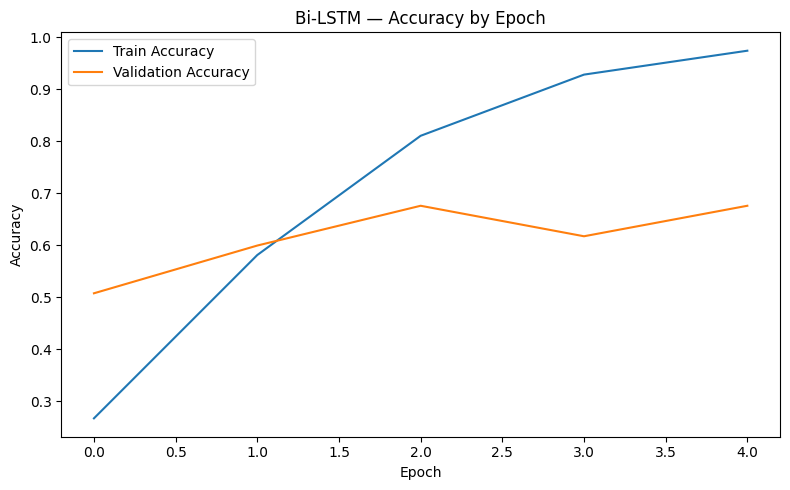

Saved: Bi-LSTM_Accuracy_by_Epoch.png


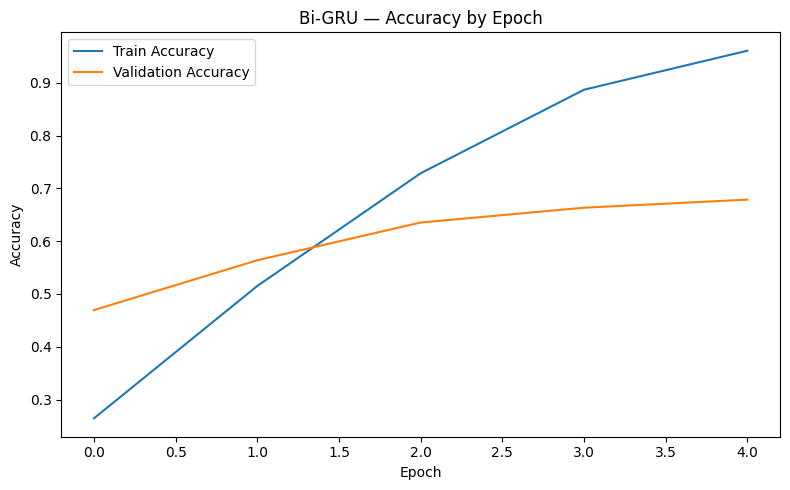

Saved: Bi-GRU_Accuracy_by_Epoch.png


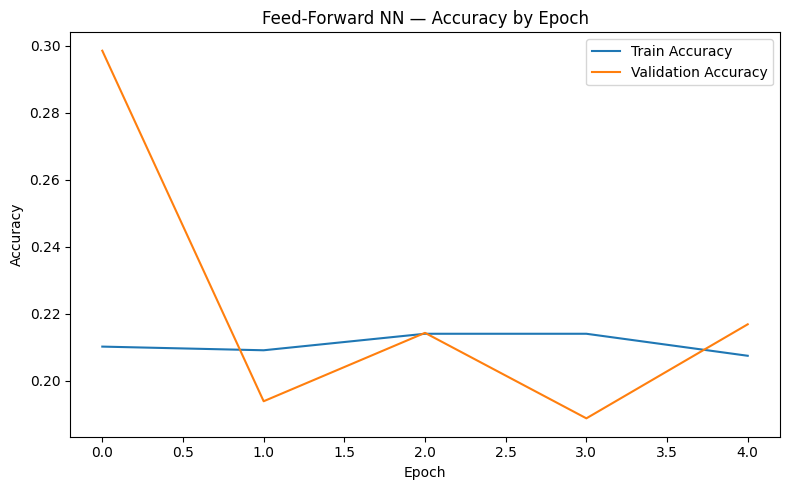

Saved: Feed-Forward_NN_Accuracy_by_Epoch.png


In [24]:
# CELL 24 — Deep learning learning curves

import os
import matplotlib.pyplot as plt

# Create folder for figures
os.makedirs("conference_figures", exist_ok=True)

for name, history in dl_histories.items():
    plt.figure(figsize=(8, 5))
    
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    
    plt.title(f"{name} — Accuracy by Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()

    # Make model name safe for filename
    safe_name = name.replace(" ", "_").replace("/", "_")

    # Save figure
    plt.savefig(
        f"conference_figures/{safe_name}_Accuracy_by_Epoch.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {safe_name}_Accuracy_by_Epoch.png")

# Part C — Transformer Models

Models:
1. `sagorsarker/bangla-bert-base`
2. `csebuetnlp/banglabert`
3. `bert-base-multilingual-cased`
4. `xlm-roberta-base`
5. `distilbert-base-multilingual-cased`

> **Kaggle setting:** Internet access must be enabled the first time Hugging Face models are downloaded, unless the model files are already attached as Kaggle inputs.


In [25]:
# CELL 25 — Transformer configuration and Hugging Face cache

TRANSFORMER_MODELS = [
    "sagorsarker/bangla-bert-base",
    "csebuetnlp/banglabert",
    "google-bert/bert-base-multilingual-cased",
    "FacebookAI/xlm-roberta-base",
    "distilbert/distilbert-base-multilingual-cased",
]

TRANSFORMER_EPOCHS = 7
TRANSFORMER_LR = 2e-5
TRANSFORMER_MAX_LENGTH = 128

# Start conservatively on GPU to reduce out-of-memory failures.
TRANSFORMER_BATCH_SIZE = 4 if torch.cuda.is_available() else 2

TRANSFORMER_CLASSES = sorted(train_df["Type"].unique())
LABEL_TO_ID = {
    label: idx
    for idx, label in enumerate(TRANSFORMER_CLASSES)
}
ID_TO_LABEL = {
    idx: label
    for label, idx in LABEL_TO_ID.items()
}
TRANSFORMER_NUM_CLASSES = len(TRANSFORMER_CLASSES)

# Use one persistent cache directory during the Kaggle session.
HF_CACHE_DIR = Path("/kaggle/working/huggingface_cache")
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Standard Hugging Face cache environment.
os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"

print("Transformer classes:", LABEL_TO_ID)
print("Transformer batch size:", TRANSFORMER_BATCH_SIZE)
print("Hugging Face cache:", HF_CACHE_DIR)

print("\nTransformer models:")
for model_name in TRANSFORMER_MODELS:
    print(" -", model_name)


Transformer classes: {'Academic Depression': 0, 'Fear': 1, 'Lonliness': 2, 'Not Depressed': 3, 'Situational Depression': 4}
Transformer batch size: 4
Hugging Face cache: /kaggle/working/huggingface_cache

Transformer models:
 - sagorsarker/bangla-bert-base
 - csebuetnlp/banglabert
 - google-bert/bert-base-multilingual-cased
 - FacebookAI/xlm-roberta-base
 - distilbert/distilbert-base-multilingual-cased


In [26]:
# CELL 26 — Hugging Face connection preflight

def check_huggingface_connection(timeout=10):
    """
    Check both DNS resolution and HTTPS access.

    Returns True only when huggingface.co is reachable.
    If False, the notebook will still try locally cached model files.
    """
    print("Checking Hugging Face connectivity...")

    try:
        ip_address = socket.gethostbyname("huggingface.co")
        print("DNS resolution: OK")
        print("huggingface.co ->", ip_address)
    except Exception as error:
        print("DNS resolution: FAILED")
        print("Reason:", repr(error))
        return False

    try:
        response = requests.get(
            "https://huggingface.co",
            timeout=timeout,
        )

        if response.status_code < 500:
            print("HTTPS connection: OK")
            print("Status code:", response.status_code)
            return True

        print("HTTPS connection returned status:", response.status_code)
        return False

    except Exception as error:
        print("HTTPS connection: FAILED")
        print("Reason:", repr(error))
        return False


HF_INTERNET_AVAILABLE = check_huggingface_connection()

if HF_INTERNET_AVAILABLE:
    print(
        "\nHugging Face is reachable. "
        "Models can be downloaded and cached."
    )
else:
    print(
        "\nHugging Face is not reachable from this Kaggle session."
        "\nThe notebook will try locally cached model files."
        "\nIf a model is not cached, that transformer will be skipped cleanly."
        "\nTo download models, enable Internet in Kaggle Notebook Settings "
        "and restart the session."
    )


Checking Hugging Face connectivity...
DNS resolution: OK
huggingface.co -> 3.169.137.5
HTTPS connection: OK
Status code: 200

Hugging Face is reachable. Models can be downloaded and cached.


In [27]:
# CELL 27 — Transformer Dataset class

class TransformerTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = [str(x) for x in texts]
        self.labels = [LABEL_TO_ID[x] for x in labels]
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [28]:
# CELL 28 — Generic Transformer classifier

class TransformerClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_classes,
        cache_dir=None,
        local_files_only=False,
    ):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(
            model_name,
            cache_dir=cache_dir,
            local_files_only=local_files_only,
        )

        hidden_size = self.transformer.config.hidden_size

        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(
        self,
        input_ids,
        attention_mask,
    ):
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        if getattr(outputs, "pooler_output", None) is not None:
            pooled = outputs.pooler_output
        else:
            pooled = outputs.last_hidden_state[:, 0]

        pooled = self.dropout(pooled)

        return self.classifier(pooled)


In [29]:
# CELL 29 — Transformer evaluation helper

def evaluate_transformer_loader(model, loader):
    model.eval()

    true_ids = []
    pred_ids = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            logits = model(input_ids, attention_mask)
            preds = logits.argmax(dim=1)

            true_ids.extend(labels.cpu().tolist())
            pred_ids.extend(preds.cpu().tolist())

    y_true = [ID_TO_LABEL[i] for i in true_ids]
    y_pred = [ID_TO_LABEL[i] for i in pred_ids]

    return y_true, y_pred

In [30]:
# CELL 30 — Train one transformer with network/cache fallback

def _load_transformer_tokenizer(model_name):
    """
    Prefer normal Hub loading when internet is available.
    If that fails, retry using only the local Hugging Face cache.
    """
    common_kwargs = {
        "cache_dir": str(HF_CACHE_DIR),
    }

    if HF_INTERNET_AVAILABLE:
        try:
            return AutoTokenizer.from_pretrained(
                model_name,
                **common_kwargs,
            )
        except OSError as network_error:
            print(
                "\nOnline tokenizer load failed. "
                "Trying the local Hugging Face cache..."
            )
            print("Online error:", repr(network_error))

    return AutoTokenizer.from_pretrained(
        model_name,
        local_files_only=True,
        **common_kwargs,
    )


def _load_transformer_model(model_name):
    """
    Prefer normal Hub loading when internet is available.
    If that fails, retry using only the local Hugging Face cache.
    """
    common_kwargs = {
        "cache_dir": str(HF_CACHE_DIR),
    }

    if HF_INTERNET_AVAILABLE:
        try:
            return TransformerClassifier(
                model_name=model_name,
                num_classes=TRANSFORMER_NUM_CLASSES,
                local_files_only=False,
                **common_kwargs,
            )
        except OSError as network_error:
            print(
                "\nOnline model load failed. "
                "Trying the local Hugging Face cache..."
            )
            print("Online error:", repr(network_error))

    return TransformerClassifier(
        model_name=model_name,
        num_classes=TRANSFORMER_NUM_CLASSES,
        local_files_only=True,
        **common_kwargs,
    )


def train_one_transformer(model_name):
    print("\n" + "=" * 90)
    print("MODEL:", model_name)
    print("=" * 90)

    tokenizer = _load_transformer_tokenizer(model_name)

    train_dataset = TransformerTextDataset(
        train_df["Data"].tolist(),
        train_df["Type"].tolist(),
        tokenizer,
        TRANSFORMER_MAX_LENGTH,
    )
    val_dataset = TransformerTextDataset(
        val_df["Data"].tolist(),
        val_df["Type"].tolist(),
        tokenizer,
        TRANSFORMER_MAX_LENGTH,
    )
    test_dataset = TransformerTextDataset(
        test_df["Data"].tolist(),
        test_df["Type"].tolist(),
        tokenizer,
        TRANSFORMER_MAX_LENGTH,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=TRANSFORMER_BATCH_SIZE,
        shuffle=False,
    )

    model = _load_transformer_model(model_name).to(DEVICE)

    optimizer = AdamW(
        model.parameters(),
        lr=TRANSFORMER_LR,
    )
    criterion = nn.CrossEntropyLoss()

    total_steps = len(train_loader) * TRANSFORMER_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, total_steps // 10),
        num_training_steps=total_steps,
    )

    best_val_macro_f1 = -1.0
    best_state = None
    history = []

    start = time.time()

    for epoch in range(TRANSFORMER_EPOCHS):
        model.train()

        train_loss_sum = 0.0
        train_examples = 0
        train_correct = 0

        progress = tqdm(
            train_loader,
            desc=(
                f"{model_name} — "
                f"Epoch {epoch + 1}/{TRANSFORMER_EPOCHS}"
            ),
        )

        for batch in progress:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            logits = model(
                input_ids,
                attention_mask,
            )

            loss = criterion(
                logits,
                labels,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()
            scheduler.step()

            batch_size = labels.size(0)
            train_loss_sum += loss.item() * batch_size
            train_examples += batch_size

            train_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

        train_loss = train_loss_sum / max(train_examples, 1)
        train_accuracy = train_correct / max(train_examples, 1)

        y_val_true, y_val_pred = evaluate_transformer_loader(
            model,
            val_loader,
        )

        val_metrics = metric_bundle(
            y_val_true,
            y_val_pred,
        )

        history.append({
            "Epoch": epoch + 1,
            "Train Loss": train_loss,
            "Train Accuracy": train_accuracy,
            "Validation Accuracy": val_metrics["Accuracy"],
            "Validation Macro F1": val_metrics["Macro F1"],
        })

        print(
            f"Epoch {epoch + 1}: "
            f"Train Loss={train_loss:.4f} | "
            f"Train Accuracy={train_accuracy:.4f} | "
            f"Val Accuracy={val_metrics['Accuracy']:.4f} | "
            f"Val Macro F1={val_metrics['Macro F1']:.4f}"
        )

        if val_metrics["Macro F1"] > best_val_macro_f1:
            best_val_macro_f1 = val_metrics["Macro F1"]

            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

    training_time = time.time() - start

    if best_state is None:
        raise RuntimeError(
            f"No valid checkpoint was created for {model_name}."
        )

    # Restore best validation checkpoint.
    model.load_state_dict(best_state)
    model.to(DEVICE)

    y_val_true, y_val_pred = evaluate_transformer_loader(
        model,
        val_loader,
    )

    y_test_true, y_test_pred = evaluate_transformer_loader(
        model,
        test_loader,
    )

    return {
        "model": model,
        "tokenizer": tokenizer,
        "history": pd.DataFrame(history),
        "y_val_true": y_val_true,
        "y_val_pred": y_val_pred,
        "y_test_true": y_test_true,
        "y_test_pred": y_test_pred,
        "training_time": training_time,
    }


In [31]:
# CELL 31 — Run all transformer models safely

transformer_runs = {}
transformer_failures = []

for model_name in TRANSFORMER_MODELS:
    print("\n" + "=" * 90)
    print("PREPARING:", model_name)
    print("=" * 90)

    try:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        run = train_one_transformer(model_name)
        short_name = model_name.split("/")[-1]

        add_model_result(
            category="Transformer",
            model_name=short_name,
            y_val_true=run["y_val_true"],
            y_val_pred=run["y_val_pred"],
            y_test_true=run["y_test_true"],
            y_test_pred=run["y_test_pred"],
            training_time=run["training_time"],
        )

        # Move completed model to CPU so the next model gets GPU memory.
        run["model"] = run["model"].to("cpu")

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        transformer_runs[short_name] = {
            "full_model_name": model_name,
            **run,
        }

        print("\nFinal test report:")
        print(classification_reports[short_name])

        print(
            f"\nSUCCESS: {short_name} completed."
        )

    except torch.cuda.OutOfMemoryError as error:
        message = (
            f"GPU out of memory for {model_name}. "
            f"Current batch size={TRANSFORMER_BATCH_SIZE}. "
            "Reduce TRANSFORMER_BATCH_SIZE to 2 if needed."
        )

        print("\nFAILED:", model_name)
        print("Reason:", message)

        transformer_failures.append({
            "Model": model_name,
            "Reason": message,
        })

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except OSError as error:
        message = (
            "The pretrained model files could not be loaded. "
            "Kaggle may not have Internet access and the model is not "
            "available in the local Hugging Face cache."
        )

        print("\nSKIPPED:", model_name)
        print("Reason:", message)
        print("Original error:", repr(error))

        transformer_failures.append({
            "Model": model_name,
            "Reason": f"{message} Original error: {repr(error)}",
        })

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as error:
        print("\nFAILED:", model_name)
        print("Reason:", repr(error))

        transformer_failures.append({
            "Model": model_name,
            "Reason": repr(error),
        })

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


print("\n" + "=" * 90)
print("TRANSFORMER RUN SUMMARY")
print("=" * 90)
print("Completed:", len(transformer_runs))
print("Failed/Skipped:", len(transformer_failures))

if transformer_failures:
    display(pd.DataFrame(transformer_failures))



PREPARING: sagorsarker/bangla-bert-base

MODEL: sagorsarker/bangla-bert-base


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch 5: Train Loss=0.3083 | Train Accuracy=0.9080 | Val Accuracy=0.6658 | Val Macro F1=0.6701


distilbert/distilbert-base-multilingual-cased — Epoch 6/7:   0%|          | 0/457 [00:00<?, ?it/s]

Epoch 6: Train Loss=0.1872 | Train Accuracy=0.9436 | Val Accuracy=0.6633 | Val Macro F1=0.6653


distilbert/distilbert-base-multilingual-cased — Epoch 7/7:   0%|          | 0/457 [00:00<?, ?it/s]

Epoch 7: Train Loss=0.1085 | Train Accuracy=0.9693 | Val Accuracy=0.6709 | Val Macro F1=0.6700

Final test report:
                        precision    recall  f1-score   support

   Academic Depression       0.64      0.64      0.64        77
                  Fear       0.61      0.68      0.64        77
             Lonliness       0.73      0.65      0.69        75
         Not Depressed       0.65      0.48      0.55        86
Situational Depression       0.40      0.52      0.45        77

              accuracy                           0.59       392
             macro avg       0.61      0.59      0.59       392
          weighted avg       0.61      0.59      0.59       392


SUCCESS: distilbert-base-multilingual-cased completed.

TRANSFORMER RUN SUMMARY
Completed: 5
Failed/Skipped: 0


In [32]:
# CELL 32 — Transformer comparison

results_frame = pd.DataFrame(results_records)

if (
    not results_frame.empty
    and "Model Category" in results_frame.columns
):
    transformer_results_df = (
        results_frame[
            results_frame["Model Category"] == "Transformer"
        ]
        .sort_values(
            "Validation Macro F1",
            ascending=False,
        )
        .reset_index(drop=True)
    )
else:
    transformer_results_df = pd.DataFrame()

if transformer_results_df.empty:
    print(
        "No transformer result is available in this run. "
        "The notebook will continue with the completed ML/DL results."
    )
else:
    display(transformer_results_df)


,Model Category,Architecture,Validation Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Validation Weighted F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Training Time (s)
0,Transformer,xlm-roberta-base,0.790816,0.795478,0.790803,0.791234,0.790525,0.752551,0.759231,0.751688,0.752442,0.752007,641.727474
1,Transformer,banglabert,0.778061,0.784766,0.776828,0.776032,0.776148,0.772959,0.778799,0.772488,0.772747,0.773088,418.319299
2,Transformer,bangla-bert-base,0.724490,0.728182,0.725534,0.725067,0.724013,0.673469,0.676354,0.674227,0.673867,0.673854,490.471035
3,Transformer,bert-base-multilingual-cased,0.686224,0.698811,0.687766,0.689687,0.688537,0.607143,0.629287,0.609818,0.613425,0.611801,510.963831
4,Transformer,distilbert-base-multilingual-cased,0.665816,0.684803,0.668943,0.670072,0.667985,0.589286,0.606053,0.592249,0.594159,0.592663,308.437757


# 7. Unified Model Comparison

The **best model is selected using Validation Macro F1**, not test performance. Test metrics are shown only for final reporting.

In [33]:
# CELL 33 — Unified validation + test comparison

all_results_df = (
    pd.DataFrame(results_records)
    .sort_values(
        ["Validation Macro F1", "Validation Accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)

format_map = {
    "Validation Accuracy": "{:.4f}",
    "Validation Macro Precision": "{:.4f}",
    "Validation Macro Recall": "{:.4f}",
    "Validation Macro F1": "{:.4f}",
    "Validation Weighted F1": "{:.4f}",
    "Test Accuracy": "{:.4f}",
    "Test Macro Precision": "{:.4f}",
    "Test Macro Recall": "{:.4f}",
    "Test Macro F1": "{:.4f}",
    "Test Weighted F1": "{:.4f}",
    "Training Time (s)": "{:.2f}",
}

display(all_results_df.style.format(format_map))

,Model Category,Architecture,Validation Accuracy,Validation Macro Precision,Validation Macro Recall,Validation Macro F1,Validation Weighted F1,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1,Test Weighted F1,Training Time (s)
0,Transformer,xlm-roberta-base,0.7908,0.7955,0.7908,0.7912,0.7905,0.7526,0.7592,0.7517,0.7524,0.7520,641.73
1,Transformer,banglabert,0.7781,0.7848,0.7768,0.7760,0.7761,0.7730,0.7788,0.7725,0.7727,0.7731,418.32
2,Transformer,bangla-bert-base,0.7245,0.7282,0.7255,0.7251,0.7240,0.6735,0.6764,0.6742,0.6739,0.6739,490.47
3,Transformer,bert-base-multilingual-cased,0.6862,0.6988,0.6878,0.6897,0.6885,0.6071,0.6293,0.6098,0.6134,0.6118,510.96
4,Deep Learning,Bi-LSTM,0.6760,0.6963,0.6741,0.6787,0.6784,0.6709,0.7036,0.6672,0.6740,0.6739,11.77
5,Classical ML,Logistic Regression,0.6633,0.6970,0.6617,0.6704,0.6694,0.6378,0.6702,0.6374,0.6463,0.6453,0.90
6,Transformer,distilbert-base-multilingual-cased,0.6658,0.6848,0.6689,0.6701,0.6680,0.5893,0.6061,0.5922,0.5942,0.5927,308.44
7,Classical ML,Random Forest,0.6633,0.6777,0.6618,0.6653,0.6656,0.6327,0.6505,0.6325,0.6362,0.6352,2.42
8,Classical ML,SVM,0.6403,0.6805,0.6380,0.6484,0.6477,0.6224,0.6591,0.6217,0.6314,0.6305,0.40
9,Deep Learning,Bi-GRU,0.6352,0.6407,0.6399,0.6364,0.6328,0.6811,0.6888,0.6832,0.6832,0.6813,7.75


In [34]:
# CELL 34 — Select the final model using validation Macro F1

if all_results_df.empty:
    raise RuntimeError("No model results are available.")

best_row = all_results_df.iloc[0]
BEST_MODEL_NAME = best_row["Architecture"]
BEST_MODEL_CATEGORY = best_row["Model Category"]

print("FINAL MODEL SELECTED FROM VALIDATION PERFORMANCE")
print("=" * 70)
print("Category:", BEST_MODEL_CATEGORY)
print("Architecture:", BEST_MODEL_NAME)
print("Validation Macro F1:", round(best_row["Validation Macro F1"], 4))
print("Test Accuracy:", round(best_row["Test Accuracy"], 4))
print("Test Macro F1:", round(best_row["Test Macro F1"], 4))
print("Test Weighted F1:", round(best_row["Test Weighted F1"], 4))

FINAL MODEL SELECTED FROM VALIDATION PERFORMANCE
Category: Transformer
Architecture: xlm-roberta-base
Validation Macro F1: 0.7912
Test Accuracy: 0.7526
Test Macro F1: 0.7524
Test Weighted F1: 0.752


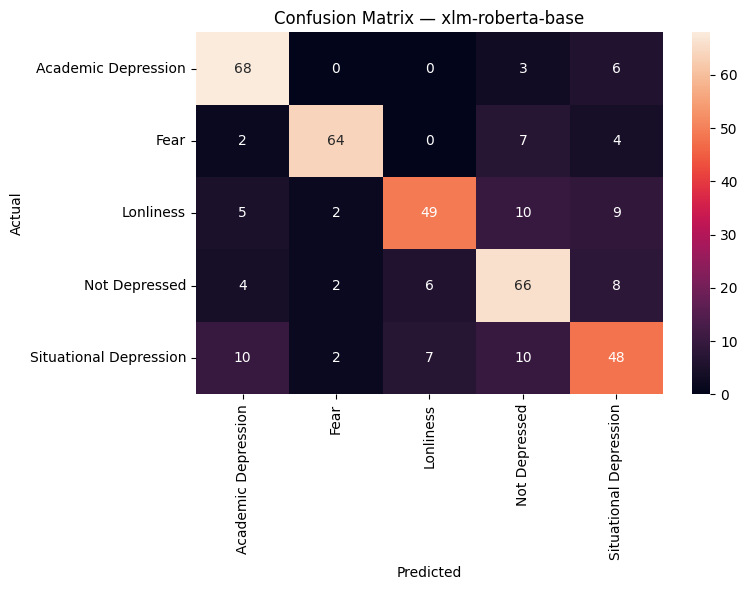

<Figure size 640x480 with 0 Axes>

In [35]:
plot_confusion_for_model(BEST_MODEL_NAME)

plt.savefig(
    "Test_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [36]:
# CELL 36 — Test classification report for the selected final model

print(classification_reports[BEST_MODEL_NAME])

                        precision    recall  f1-score   support

   Academic Depression       0.76      0.88      0.82        77
                  Fear       0.91      0.83      0.87        77
             Lonliness       0.79      0.65      0.72        75
         Not Depressed       0.69      0.77      0.73        86
Situational Depression       0.64      0.62      0.63        77

              accuracy                           0.75       392
             macro avg       0.76      0.75      0.75       392
          weighted avg       0.76      0.75      0.75       392



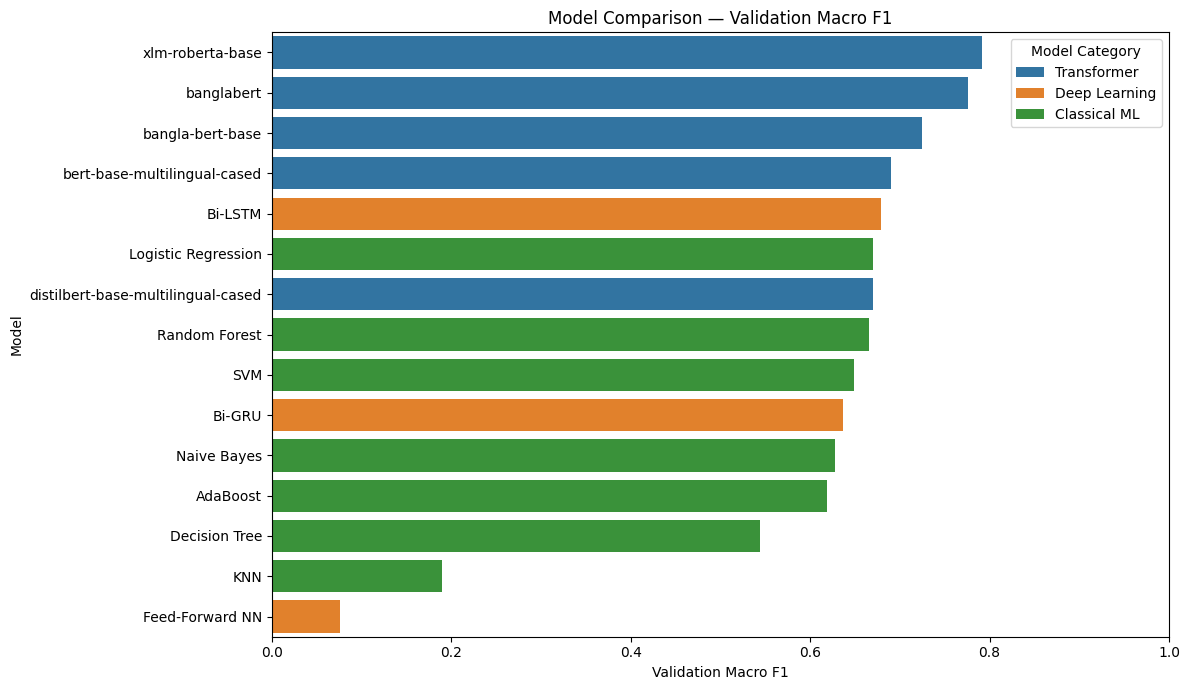

In [37]:
# CELL 37 — Validation Macro F1 comparison chart

plt.figure(figsize=(12, 7))
sns.barplot(
    data=all_results_df,
    x="Validation Macro F1",
    y="Architecture",
    hue="Model Category",
    dodge=False,
)

plt.xlim(0, 1)
plt.title("Model Comparison — Validation Macro F1")
plt.xlabel("Validation Macro F1")
plt.ylabel("Model")
plt.tight_layout()

# Save figure
plt.savefig(
    "Validation_Macro_F1_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Optional Word Cloud

Bangla word clouds require a font that contains Bengali glyphs. The code searches common Kaggle/system font locations automatically. If a suitable Bengali font cannot be found, it skips the visualization instead of producing broken squares.

Bangla font downloaded successfully.
Font path: /kaggle/working/fonts/NotoSansBengali.ttf
Font size: 463668 bytes

Bangla font ready for use.
Total text length: 277815


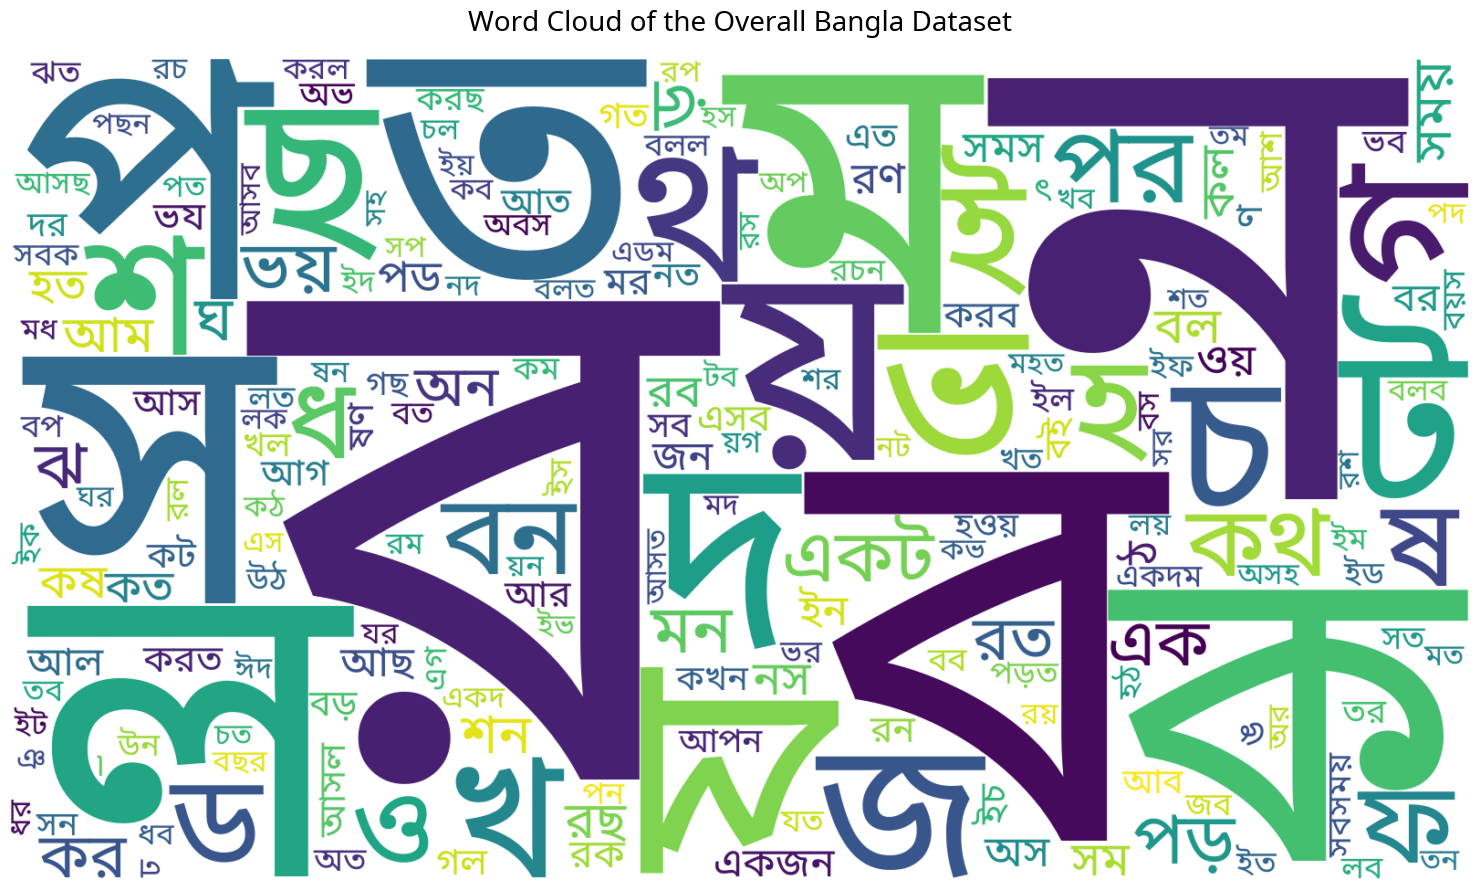

In [38]:
# ============================================================
# CELL 38 — COMPLETE BANGLA WORD CLOUD FOR KAGGLE
# Downloads Bangla font automatically + generates word cloud
# ============================================================

import os
import requests
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib import font_manager


# ------------------------------------------------------------
# 1. DOWNLOAD BANGLA FONT
# ------------------------------------------------------------

FONT_DIR = "/kaggle/working/fonts"
os.makedirs(FONT_DIR, exist_ok=True)

bangla_font = os.path.join(
    FONT_DIR,
    "NotoSansBengali.ttf"
)

font_url = (
    "https://raw.githubusercontent.com/google/fonts/main/"
    "ofl/notosansbengali/"
    "NotoSansBengali%5Bwdth%2Cwght%5D.ttf"
)


if not os.path.exists(bangla_font):

    print("Downloading Bangla font...")

    response = requests.get(
        font_url,
        timeout=30
    )

    response.raise_for_status()

    with open(
        bangla_font,
        "wb"
    ) as f:

        f.write(response.content)

    print("Bangla font downloaded successfully.")

else:

    print("Bangla font already exists.")


print("Font path:", bangla_font)
print(
    "Font size:",
    os.path.getsize(bangla_font),
    "bytes"
)


# ------------------------------------------------------------
# 2. VERIFY FONT
# ------------------------------------------------------------

bangla_font_prop = font_manager.FontProperties(
    fname=bangla_font
)

print("\nBangla font ready for use.")


# ------------------------------------------------------------
# 3. PREPARE DATA
# ------------------------------------------------------------

if "Data" not in df.columns:

    raise KeyError(
        "Column 'Data' was not found in df.\n"
        f"Available columns: {df.columns.tolist()}"
    )


all_text = " ".join(
    df["Data"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)


if all_text.strip() == "":

    raise ValueError(
        "No text was found in the 'Data' column."
    )


print(
    "Total text length:",
    len(all_text)
)


# ------------------------------------------------------------
# 4. GENERATE BANGLA WORD CLOUD
# ------------------------------------------------------------

wordcloud = WordCloud(

    width=1600,
    height=900,

    background_color="white",

    font_path=bangla_font,

    max_words=200,

    collocations=False,

    random_state=42,

    prefer_horizontal=0.9

).generate(all_text)


# ------------------------------------------------------------
# 5. DISPLAY WORD CLOUD
# ------------------------------------------------------------

plt.figure(
    figsize=(16, 9)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of the Overall Bangla Dataset",
    fontproperties=bangla_font_prop,
    fontsize=20,
    pad=20
)

plt.tight_layout()

plt.show()

# 9. Save Results and Reusable Artifacts

In [39]:
# CELL 39 — Save result tables

all_results_df.to_excel(
    OUTPUT_DIR / "final_model_comparison.xlsx",
    index=False,
)
all_results_df.to_csv(
    OUTPUT_DIR / "final_model_comparison.csv",
    index=False,
)

ml_results_df.to_csv(
    OUTPUT_DIR / "classical_ml_results.csv",
    index=False,
)

dl_results_df.to_csv(
    OUTPUT_DIR / "deep_learning_results.csv",
    index=False,
)

if not transformer_results_df.empty:
    transformer_results_df.to_csv(
        OUTPUT_DIR / "transformer_results.csv",
        index=False,
    )

print("Saved final result tables.")

Saved final result tables.


In [40]:
# CELL 40 — Save classical ML preprocessing and models

joblib.dump(
    tfidf_vectorizer,
    OUTPUT_DIR / "tfidf_vectorizer.joblib",
)

for name, model in ml_trained_models.items():
    safe_name = re.sub(r"[^A-Za-z0-9_-]", "_", name)
    joblib.dump(
        model,
        OUTPUT_DIR / f"ml_{safe_name}.joblib",
    )

print("Saved TF-IDF vectorizer and classical ML models.")

Saved TF-IDF vectorizer and classical ML models.


In [41]:
# CELL 41 — Save deep learning artifacts

joblib.dump(
    keras_tokenizer,
    OUTPUT_DIR / "keras_tokenizer.joblib",
)
joblib.dump(
    keras_label_encoder,
    OUTPUT_DIR / "keras_label_encoder.joblib",
)

for name, model in dl_models_trained.items():
    safe_name = re.sub(r"[^A-Za-z0-9_-]", "_", name)
    model.save(OUTPUT_DIR / f"dl_{safe_name}.keras")

print("Saved Keras tokenizer, label encoder and deep learning models.")

Saved Keras tokenizer, label encoder and deep learning models.


In [42]:
# CELL 42 — Save the best transformer correctly

if BEST_MODEL_CATEGORY == "Transformer" and BEST_MODEL_NAME in transformer_runs:
    run = transformer_runs[BEST_MODEL_NAME]
    save_dir = OUTPUT_DIR / "best_transformer"
    save_dir.mkdir(parents=True, exist_ok=True)

    # Save the custom classification wrapper state.
    torch.save(
        {
            "state_dict": run["model"].state_dict(),
            "base_model_name": run["full_model_name"],
            "class_names": TRANSFORMER_CLASSES,
            "max_length": TRANSFORMER_MAX_LENGTH,
        },
        save_dir / "classifier_checkpoint.pt",
    )

    # Save tokenizer files.
    run["tokenizer"].save_pretrained(save_dir)

    print("Best transformer checkpoint saved to:", save_dir)
else:
    print("The validation-selected final model is not a transformer; transformer checkpoint not saved as final model.")

Best transformer checkpoint saved to: /kaggle/working/model_outputs/best_transformer


In [43]:
# CELL 43 — Save experiment configuration

experiment_config = {
    "dataset": DATASET_NAME,
    "seed": SEED,
    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15,
        "stratified": True,
    },
    "selection_metric": "Validation Macro F1",
    "preprocessing": {
        "bangla_stopword_removal": True,
        "number_of_stopwords": len(BANGLA_STOPWORDS),
    },
    "tfidf": {
        "max_features": TFIDF_MAX_FEATURES,
        "ngram_range": [1, 2],
        "min_df": 2,
        "sublinear_tf": True,
    },
    "deep_learning": {
        "max_words": MAX_WORDS,
        "max_len": MAX_LEN,
        "epochs": DL_EPOCHS,
        "batch_size": DL_BATCH_SIZE,
    },
    "transformers": {
        "models": TRANSFORMER_MODELS,
        "epochs": TRANSFORMER_EPOCHS,
        "learning_rate": TRANSFORMER_LR,
        "max_length": TRANSFORMER_MAX_LENGTH,
        "batch_size": TRANSFORMER_BATCH_SIZE,
        "huggingface_cache": str(HF_CACHE_DIR),
        "internet_available_at_preflight": HF_INTERNET_AVAILABLE,
        "completed_models": list(transformer_runs.keys()),
        "failed_or_skipped_models": transformer_failures,
    },
    "selected_final_model": {
        "category": BEST_MODEL_CATEGORY,
        "architecture": BEST_MODEL_NAME,
    },
}

with open(
    OUTPUT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(experiment_config, f, ensure_ascii=False, indent=2)

print("Saved experiment_config.json")

Saved experiment_config.json


In [44]:
# CELL 44 — Final output inventory

print("FILES CREATED IN /kaggle/working/model_outputs")
print("=" * 75)

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"{path.relative_to(OUTPUT_DIR)} — {size_mb:.2f} MB")

FILES CREATED IN /kaggle/working/model_outputs
best_transformer/classifier_checkpoint.pt — 1060.75 MB
best_transformer/tokenizer.json — 16.00 MB
best_transformer/tokenizer_config.json — 0.00 MB
classical_ml_results.csv — 0.00 MB
cleaned_Dataset_final.xlsx — 0.22 MB
deep_learning_results.csv — 0.00 MB
dl_Bi-GRU.keras — 15.55 MB
dl_Bi-LSTM.keras — 15.83 MB
dl_Feed-Forward_NN.keras — 14.87 MB
experiment_config.json — 0.00 MB
final_model_comparison.csv — 0.00 MB
final_model_comparison.xlsx — 0.01 MB
keras_label_encoder.joblib — 0.00 MB
keras_tokenizer.joblib — 0.41 MB
ml_AdaBoost.joblib — 0.18 MB
ml_Decision_Tree.joblib — 0.11 MB
ml_KNN.joblib — 0.27 MB
ml_Logistic_Regression.joblib — 0.11 MB
ml_Naive_Bayes.joblib — 0.21 MB
ml_Random_Forest.joblib — 47.70 MB
ml_SVM.joblib — 0.32 MB
test_data.xlsx — 0.04 MB
tfidf_vectorizer.joblib — 0.11 MB
train_data.xlsx — 0.16 MB
transformer_results.csv — 0.00 MB
val_data.xlsx — 0.04 MB


# Conference Reporting Notes

Use the results generated by this notebook, not manually entered values.

Recommended methodology wording:

> The dataset was cleaned prior to splitting and divided using a stratified 60:20:20 train-validation-test protocol. Classical machine-learning models were trained using TF-IDF representations, while recurrent neural networks learned task-specific embeddings. Transformer models were fine-tuned from pretrained multilingual or Bangla language representations. Model selection was performed using validation Macro F1, and final performance was reported on the held-out test set.

### Key corrections from the original notebook
- Google Sheets loading removed
- Kaggle dataset loading added
- Repeated imports/loading/preprocessing removed
- One consistent split used by all models
- Duplicate text leakage reduced before splitting
- TF-IDF and Keras tokenizer fitted on training data only
- Transformer training consolidated into one reusable pipeline
- Best transformer checkpoint restored using validation Macro F1
- Final model selected from validation performance, not test performance
- Manually typed conference result values removed